In [1]:
!pip install -q stardist csbdeep zarr geff networkx scipy scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 86.9 MB/s eta 0:00:00:00:0100:01


In [18]:
# %% [code]
import numpy as np
import zarr
import networkx as nx
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from skimage.registration import phase_cross_correlation
from stardist.models import StarDist3D
from csbdeep.utils import normalize

# Load the off-the-shelf temporary model
print("Loading StarDist3D...")
model = StarDist3D.from_pretrained('3D_demo')
print("Model loaded successfully!")

Loading StarDist3D...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Model loaded successfully!


In [19]:
# motion vector code
def get_motion_vector(centroid, label_id, labels_T, frame_T, frame_T1, r=10):
    """
    Extracts a 3D motion vector for a single cell using Masked Phase Correlation.
    r: radius of the bounding box crop (r=10 means a 20x20x20 box).
    """
    z, y, x = int(centroid[0]), int(centroid[1]), int(centroid[2])
    Z_max, Y_max, X_max = frame_T.shape

    # Ensure crops don't go out of bounds of the image edges
    z_min, z_max = max(0, z-r), min(Z_max, z+r)
    y_min, y_max = max(0, y-r), min(Y_max, y+r)
    x_min, x_max = max(0, x-r), min(X_max, x+r)

    # 1. Crop from Frame T
    crop_T = frame_T[z_min:z_max, y_min:y_max, x_min:x_max].copy()
    mask_crop = labels_T[z_min:z_max, y_min:y_max, x_min:x_max]

    # FEATURE ENGINEERING: Zero out everything except our specific cell
    crop_T[mask_crop != label_id] = 0

    # 2. Crop from Frame T+1 at the EXACT same coordinates
    crop_T1 = frame_T1[z_min:z_max, y_min:y_max, x_min:x_max]

    # 3. Calculate 3D shift. If crops are too small (edge of image), assume no motion.
    if crop_T.shape == crop_T1.shape and 0 not in crop_T.shape:
        shift, _, _ = phase_cross_correlation(
            reference_image=crop_T, 
            moving_image=crop_T1, 
            upsample_factor=10 # Sub-pixel accuracy
        )
        return shift # Returns [dz, dy, dx]
    else:
        return np.array([0.0, 0.0, 0.0])

In [31]:
# edge detection code
import scipy.ndimage as ndi

def preprocess_3d_volume(vol, alpha=1.2, sigma=(0.8, 1.5, 1.5)):
    """
    Applies 3D edge detection and unsharp sharpening to a 3D volume (Z, Y, X).
    
    alpha: Sharpening strength (higher = crisper edges, but amplifies noise. 1.0 - 1.5 is sweet spot).
    sigma: Gaussian blur standard deviation (Z is smaller due to lower Z resolution).
    """
    vol_float = vol.astype(np.float32)
    
    # 1. Low-pass blurred version of the volume
    blurred = ndi.gaussian_filter(vol_float, sigma=sigma)
    
    # 2. Extract high-frequency 3D edges (Laplacian-like residual)
    edges = vol_float - blurred
    
    # 3. Add edges back to sharpen cell boundaries
    sharpened = vol_float + alpha * edges
    
    # 4. Clip negative values caused by subtraction
    sharpened = np.clip(sharpened, 0, None)
    
    return sharpened, edges

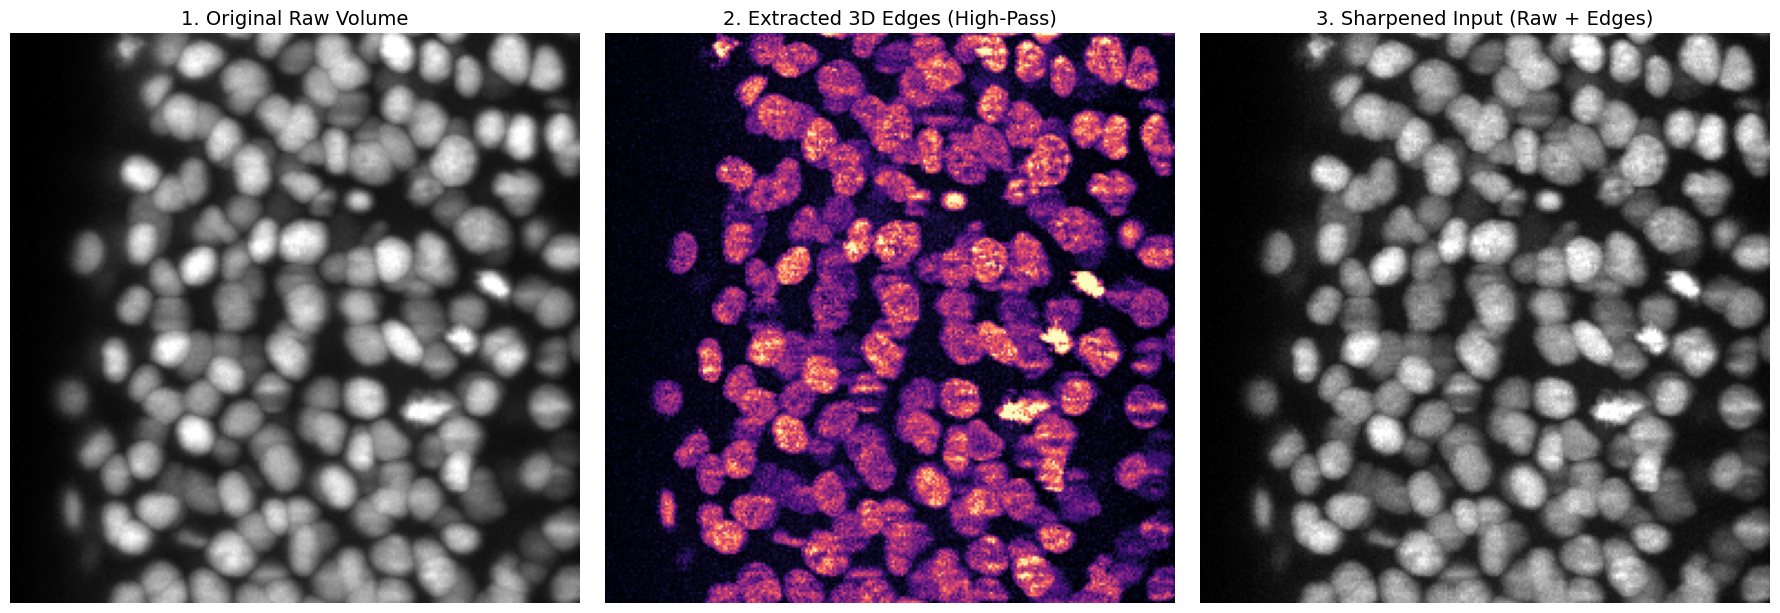

In [32]:
# Edge detection comparision
import matplotlib.pyplot as plt

# Take frame 0 to inspect
raw_frame = np.asarray(arr[0])
sharpened_frame, edges = preprocess_3d_volume(raw_frame, alpha=1.4)

# Project to 2D for visualization
raw_mip = raw_frame.max(axis=0)
edges_mip = edges.max(axis=0)
sharp_mip = sharpened_frame.max(axis=0)

# Normalize for plotting
def norm_mip(img):
    lo, hi = np.percentile(img, [1, 99.5])
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(norm_mip(raw_mip), cmap='gray')
axes[0].set_title("1. Original Raw Volume", fontsize=14)
axes[0].axis('off')

axes[1].imshow(norm_mip(edges_mip), cmap='magma')
axes[1].set_title("2. Extracted 3D Edges (High-Pass)", fontsize=14)
axes[1].axis('off')

axes[2].imshow(norm_mip(sharp_mip), cmap='gray')
axes[2].set_title("3. Sharpened Input (Raw + Edges)", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# SORT tracking class
class Track:
    def __init__(self, track_id, initial_centroid, initial_label):
        self.track_id = track_id
        self.history = [initial_centroid] # List of (z, y, x)
        self.current_centroid = initial_centroid
        self.current_label = initial_label
        self.motion_vector = np.array([0.0, 0.0, 0.0])
        self.time_since_update = 0

class MotionSORT:
    def __init__(self, distance_threshold=15.0, max_age=3):
        self.tracks = []
        self.next_track_id = 1
        self.distance_threshold = distance_threshold
        self.max_age = max_age
        self.graph = nx.DiGraph() # Storing tracks as a graph

    def update(self, frame_T, frame_T1, labels_T, centroids_T1, labels_T1, timepoint):
        # 1. PREDICT: Move existing tracks using motion vectors
        predicted_centroids = []
        active_tracks = [t for t in self.tracks if t.time_since_update <= self.max_age]
        
        for track in active_tracks:
            track.motion_vector = get_motion_vector(
                track.current_centroid, track.current_label, 
                labels_T, frame_T, frame_T1
            )
            pred_pos = track.current_centroid + track.motion_vector
            predicted_centroids.append(pred_pos)

        # 2. MATCH: Hungarian Algorithm
        matched_indices = []
        unmatched_tracks = []
        unmatched_detections = list(range(len(centroids_T1)))

        if len(active_tracks) > 0 and len(centroids_T1) > 0:
            cost_matrix = cdist(np.array(predicted_centroids), centroids_T1, metric='euclidean')
            row_ind, col_ind = linear_sum_assignment(cost_matrix)

            for r, c in zip(row_ind, col_ind):
                if cost_matrix[r, c] < self.distance_threshold:
                    matched_indices.append((r, c))
                    unmatched_detections.remove(c)
                else:
                    unmatched_tracks.append(r)

        # Helper to safely sample the 3D label mask at a centroid
        def get_label_at_coords(centroid, label_mask, det_idx):
            cz = int(np.clip(round(centroid[0]), 0, label_mask.shape[0] - 1))
            cy = int(np.clip(round(centroid[1]), 0, label_mask.shape[1] - 1))
            cx = int(np.clip(round(centroid[2]), 0, label_mask.shape[2] - 1))
            lbl = label_mask[cz, cy, cx]
            return lbl if lbl != 0 else (det_idx + 1) # StarDist fallback (1-based ID)

        # 3. UPDATE: Update matched tracks
        for r, c in matched_indices:
            track = active_tracks[r]
            new_centroid = centroids_T1[c]
            new_label = get_label_at_coords(new_centroid, labels_T1, c) # FIXED HERE
            
            # Add node and link edge to graph
            prev_node = f"T{timepoint-1}_ID{track.track_id}"
            curr_node = f"T{timepoint}_ID{track.track_id}"
            self.graph.add_node(curr_node, t=timepoint, z=new_centroid[0], y=new_centroid[1], x=new_centroid[2])
            self.graph.add_edge(prev_node, curr_node)

            track.current_centroid = new_centroid
            track.current_label = new_label
            track.history.append(new_centroid)
            track.time_since_update = 0

        # 4. BIRTHS: Initialize new tracks for unmatched detections
        for c in unmatched_detections:
            new_centroid = centroids_T1[c]
            new_label = get_label_at_coords(new_centroid, labels_T1, c) # FIXED HERE
            new_track = Track(self.next_track_id, new_centroid, new_label)
            
            curr_node = f"T{timepoint}_ID{self.next_track_id}"
            self.graph.add_node(curr_node, t=timepoint, z=new_centroid[0], y=new_centroid[1], x=new_centroid[2])
            
            self.tracks.append(new_track)
            self.next_track_id += 1

        # 5. DEATHS: Increment age of unmatched tracks
        unmatched_track_indices = [r for r in range(len(active_tracks)) if r not in [m[0] for m in matched_indices]]
        for r in unmatched_track_indices:
            active_tracks[r].time_since_update += 1

In [34]:
# Tracking for 5 frames accross sample 1
import numpy as np
import zarr
import scipy.ndimage as ndi
from csbdeep.utils import normalize

# ==========================================
# 1. 3D Edge & Sharpening Preprocessor
# ==========================================
def preprocess_3d_volume(vol, alpha=1.2, sigma=(0.8, 1.5, 1.5)):
    vol_float = vol.astype(np.float32)
    blurred = ndi.gaussian_filter(vol_float, sigma=sigma)
    edges = vol_float - blurred
    sharpened = vol_float + alpha * edges
    return np.clip(sharpened, 0, None)

# ==========================================
# 2. Load the Zarr Data
# ==========================================
zarr_path = "/kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr"
print(f"Loading data from {zarr_path}...")
z = zarr.open(zarr_path, mode="r")
arr = z['0']  # Shape: (T, Z, Y, X)
T = arr.shape[0]

# ==========================================
# 3. Initialize Tracker & Parameters
# ==========================================
tracker = MotionSORT(distance_threshold=12.0)
MAX_FRAMES = 5  # Test on 5 frames

print(f"Starting tracking with 3D Edge Sharpening across {MAX_FRAMES} frames...")

# ==========================================
# 4. Frame 0: Preprocess, Detect, & Seed Tracks
# ==========================================
frame_0_raw = np.asarray(arr[0])
frame_0_sharp = preprocess_3d_volume(frame_0_raw, alpha=1.2)

# Pass the sharpened frame to StarDist
frame_0_norm = normalize(frame_0_sharp, 1, 99.8, axis=(0, 1, 2))
labels_prev, details_prev = model.predict_instances(frame_0_norm)
centroids_prev = details_prev['points']

# Initialize birth tracks for Frame 0
for i, centroid in enumerate(centroids_prev):
    cz = int(np.clip(round(centroid[0]), 0, labels_prev.shape[0] - 1))
    cy = int(np.clip(round(centroid[1]), 0, labels_prev.shape[1] - 1))
    cx = int(np.clip(round(centroid[2]), 0, labels_prev.shape[2] - 1))
    label_id = labels_prev[cz, cy, cx] if labels_prev[cz, cy, cx] != 0 else (i + 1)

    track = Track(tracker.next_track_id, centroid, label_id)
    node_name = f"T0_ID{tracker.next_track_id}"
    tracker.graph.add_node(node_name, t=0, z=centroid[0], y=centroid[1], x=centroid[2])
    tracker.tracks.append(track)
    tracker.next_track_id += 1

print(f"Frame T=0 initialized with {len(centroids_prev)} cell detections.")

# ==========================================
# 5. Time Loop: Frames 1 to MAX_FRAMES - 1
# ==========================================
frame_prev_sharp = frame_0_sharp

for t in range(1, MAX_FRAMES):
    print(f"Processing Frame T={t} (Sharpening + Detecting + Tracking)...")
    
    # Load and sharpen current frame
    frame_curr_raw = np.asarray(arr[t])
    frame_curr_sharp = preprocess_3d_volume(frame_curr_raw, alpha=1.2)
    
    # 1. Detect on the sharpened frame
    frame_curr_norm = normalize(frame_curr_sharp, 1, 99.8, axis=(0, 1, 2))
    labels_curr, details_curr = model.predict_instances(frame_curr_norm)
    centroids_curr = details_curr['points']

    # 2. Update Tracker (using sharpened frames for cross-correlation too!)
    tracker.update(
        frame_T = frame_prev_sharp, 
        frame_T1 = frame_curr_sharp, 
        labels_T = labels_prev, 
        centroids_T1 = centroids_curr, 
        labels_T1 = labels_curr,
        timepoint = t
    )

    # Shift references for next iteration
    labels_prev = labels_curr
    frame_prev_sharp = frame_curr_sharp

print("\n==========================================")
print(f"Tracking complete with Sharpening!")
print(f"Total cell detections (nodes): {tracker.graph.number_of_nodes()}")
print(f"Total connections made (edges): {tracker.graph.number_of_edges()}")
print("==========================================")

Loading data from /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr...
Starting tracking with 3D Edge Sharpening across 5 frames...
Frame T=0 initialized with 135 cell detections.
Processing Frame T=1 (Sharpening + Detecting + Tracking)...
Processing Frame T=2 (Sharpening + Detecting + Tracking)...


868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(7974300400000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(37256484000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(16680733000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(5080889700000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(10041797000000.0). Either the reference or movi

Processing Frame T=3 (Sharpening + Detecting + Tracking)...


868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(22364885000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(23157734000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(10057075000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(44004160000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(13044788000000.0). Either the reference or mo

Processing Frame T=4 (Sharpening + Detecting + Tracking)...


868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(17442384000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(9382644000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(34528850000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(13031344000000.0). Either the reference or moving image may be empty.
868379201.py (27): Could not determine RMS error between images with the normalized average intensities np.float32(0.0) and np.float32(14424348000000.0). Either the reference or mov


Tracking complete with Sharpening!
Total cell detections (nodes): 801
Total connections made (edges): 418


In [35]:
# Validation
from geff import read
from scipy.spatial import KDTree

print("Loading Ground Truth .geff graph...")
gt_graph, metadata = read("/kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff", backend="networkx")

# Inspect the first GT node to see its exact attribute format
sample_node_id, sample_attrs = next(iter(gt_graph.nodes(data=True)))
print(f"Sample Ground Truth Node: {sample_node_id} -> {sample_attrs}")

# 1. Extract ground truth nodes for frames t=0 to MAX_FRAMES-1
gt_nodes_by_time = {t: [] for t in range(MAX_FRAMES)}

for node, data in gt_graph.nodes(data=True):
    # Support multiple possible key names ('t', 'time', 'frame')
    t = data.get('t', data.get('time', data.get('frame', None)))
    if t is not None and t < MAX_FRAMES:
        # Check if coordinates are stored as separate keys or an array
        if 'z' in data and 'y' in data and 'x' in data:
            coord = np.array([data['z'], data['y'], data['x']])
        elif 'centroid' in data:
            coord = np.array(data['centroid'])
        else:
            continue
        gt_nodes_by_time[t].append((node, coord))

# 2. Extract our tracker's predicted nodes (skipping any placeholder nodes where t is None)
pred_nodes_by_time = {t: [] for t in range(MAX_FRAMES)}

for node, data in tracker.graph.nodes(data=True):
    t = data.get('t')
    if t is not None and t in pred_nodes_by_time:
        if 'z' in data and 'y' in data and 'x' in data:
            pred_nodes_by_time[t].append((node, np.array([data['z'], data['y'], data['x']])))

# 3. Map GT nodes to our predicted nodes using spatial nearest neighbor (KDTree)
gt_to_pred_map = {}
MATCH_DISTANCE_TOLERANCE = 12.0 # In voxels

for t in range(MAX_FRAMES):
    if len(gt_nodes_by_time[t]) == 0 or len(pred_nodes_by_time[t]) == 0:
        continue
    
    pred_ids, pred_coords = zip(*pred_nodes_by_time[t])
    tree = KDTree(pred_coords)
    
    for gt_id, gt_coord in gt_nodes_by_time[t]:
        dist, idx = tree.query(gt_coord)
        if dist <= MATCH_DISTANCE_TOLERANCE:
            gt_to_pred_map[gt_id] = pred_ids[idx]

print(f"\nMatched {len(gt_to_pred_map)} ground truth cells to our StarDist detections.")

# 4. Check edge overlap (Did our tracker link the same nodes that Ground Truth linked?)
correct_edges = 0
total_gt_edges = 0

for u, v in gt_graph.edges():
    u_data = gt_graph.nodes[u]
    v_data = gt_graph.nodes[v]
    
    u_time = u_data.get('t', u_data.get('time', u_data.get('frame', None)))
    v_time = v_data.get('t', v_data.get('time', v_data.get('frame', None)))
    
    if u_time is not None and v_time is not None and max(u_time, v_time) < MAX_FRAMES:
        total_gt_edges += 1
        if u in gt_to_pred_map and v in gt_to_pred_map:
            pred_u = gt_to_pred_map[u]
            pred_v = gt_to_pred_map[v]
            if tracker.graph.has_edge(pred_u, pred_v):
                correct_edges += 1

print("\n==========================================")
print("       BASELINE EVALUATION REPORT         ")
print("==========================================")
print(f"Total Ground Truth Edges (t < {MAX_FRAMES}): {total_gt_edges}")
print(f"Correctly Tracked Edges: {correct_edges}")

if total_gt_edges > 0:
    recall = (correct_edges / total_gt_edges) * 100
    print(f"Edge Tracking Accuracy (Recall): {recall:.2f}%")
else:
    print("No ground truth edges found in the first 5 frames.")
    print("Tip: Because of the 1:300 sparsity, the first ground truth edges might appear in later frames.")

Loading Ground Truth .geff graph...
Sample Ground Truth Node: 11000000075 -> {'x': 249, 'z': 63, 't': 0, 'y': 222}

Matched 1 ground truth cells to our StarDist detections.

       BASELINE EVALUATION REPORT         
Total Ground Truth Edges (t < 5): 2
Correctly Tracked Edges: 0
Edge Tracking Accuracy (Recall): 0.00%


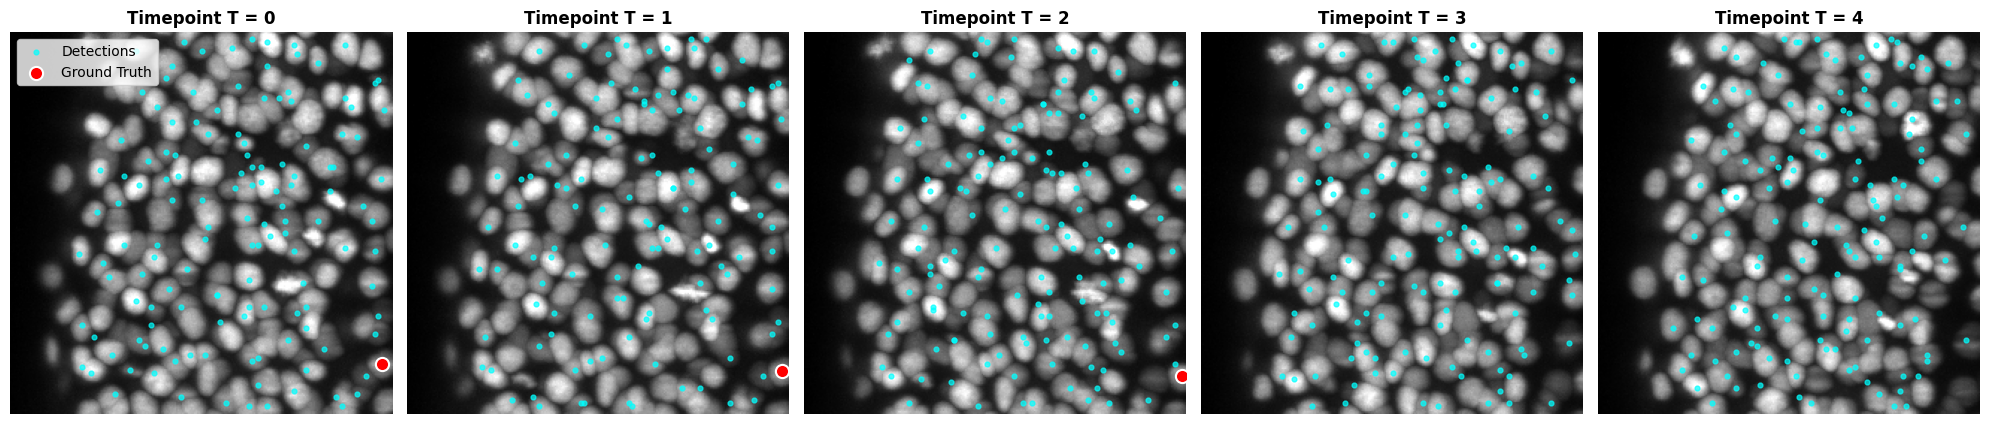


GIF saved to /kaggle/working/tracking_overlay.gif


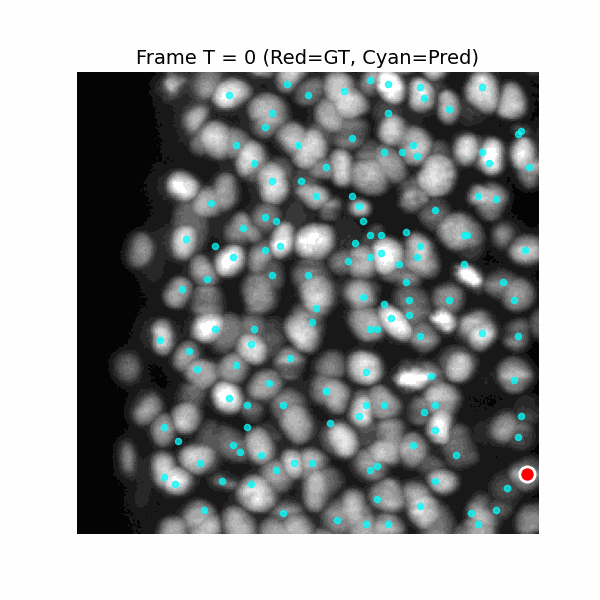

In [36]:
# Visual comparision
import matplotlib.pyplot as plt
import numpy as np
import imageio
from IPython.display import Image, display

# 1. Collect Ground Truth and Predicted coordinates per timepoint (Y, X for 2D MIP)
gt_by_t = {t: [] for t in range(MAX_FRAMES)}
for node, data in gt_graph.nodes(data=True):
    t = data.get('t', data.get('time', None))
    if t is not None and t < MAX_FRAMES:
        gt_by_t[t].append((data['x'], data['y'], data['z'], node))

pred_by_t = {t: [] for t in range(MAX_FRAMES)}
for node, data in tracker.graph.nodes(data=True):
    t = data.get('t')
    if t is not None and t < MAX_FRAMES:
        if 'x' in data and 'y' in data:
            pred_by_t[t].append((data['x'], data['y'], data['z'], node))

# -------------------------------------------------------------
# Part A: Static 5-Frame Side-by-Side Gallery
# -------------------------------------------------------------
fig, axes = plt.subplots(1, MAX_FRAMES, figsize=(4 * MAX_FRAMES, 5))
if MAX_FRAMES == 1:
    axes = [axes]

for t in range(MAX_FRAMES):
    vol = np.asarray(arr[t])
    mip_xy = vol.max(axis=0) # Maximum Intensity Projection along Z
    
    # Contrast adjustment
    lo, hi = np.percentile(mip_xy, [1, 99.5])
    mip_norm = np.clip((mip_xy - lo) / (hi - lo + 1e-8), 0, 1)
    
    ax = axes[t]
    ax.imshow(mip_norm, cmap='gray')
    ax.set_title(f"Timepoint T = {t}", fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Plot Predicted Detections (Cyan dots)
    if len(pred_by_t[t]) > 0:
        px, py = [p[0] for p in pred_by_t[t]], [p[1] for p in pred_by_t[t]]
        ax.scatter(px, py, c='cyan', s=12, alpha=0.7, label='Detections' if t == 0 else "")
    
    # Plot Ground Truth Annotations (Red target rings)
    if len(gt_by_t[t]) > 0:
        gx, gy = [g[0] for g in gt_by_t[t]], [g[1] for g in gt_by_t[t]]
        ax.scatter(gx, gy, c='red', s=90, marker='o', edgecolors='white', linewidth=1.5, label='Ground Truth' if t == 0 else "")

# Add legend to first plot
axes[0].legend(loc='upper left', framealpha=0.8)
plt.tight_layout()
plt.savefig("/kaggle/working/comparison_5frames.png", dpi=200, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# Part B: Animated Slideshow / GIF
# -------------------------------------------------------------
gif_frames = []

for t in range(MAX_FRAMES):
    vol = np.asarray(arr[t])
    mip_xy = vol.max(axis=0)
    lo, hi = np.percentile(mip_xy, [1, 99.5])
    mip_norm = np.clip((mip_xy - lo) / (hi - lo + 1e-8), 0, 1)
    
    fig_gif, ax_gif = plt.subplots(figsize=(6, 6))
    ax_gif.imshow(mip_norm, cmap='gray')
    ax_gif.set_title(f"Frame T = {t} (Red=GT, Cyan=Pred)", fontsize=14)
    ax_gif.axis('off')
    
    if len(pred_by_t[t]) > 0:
        px, py = [p[0] for p in pred_by_t[t]], [p[1] for p in pred_by_t[t]]
        ax_gif.scatter(px, py, c='cyan', s=20, alpha=0.7)
        
    if len(gt_by_t[t]) > 0:
        gx, gy = [g[0] for g in gt_by_t[t]], [g[1] for g in gt_by_t[t]]
        ax_gif.scatter(gx, gy, c='red', s=120, marker='o', edgecolors='white', linewidth=2)
        
    fig_gif.canvas.draw()
    image_rgba = np.asarray(fig_gif.canvas.buffer_rgba())
    gif_frames.append(image_rgba)
    plt.close(fig_gif)

imageio.mimsave("/kaggle/working/tracking_overlay.gif", gif_frames, fps=2, loop=0)
print("\nGIF saved to /kaggle/working/tracking_overlay.gif")
display(Image(filename="/kaggle/working/tracking_overlay.gif"))

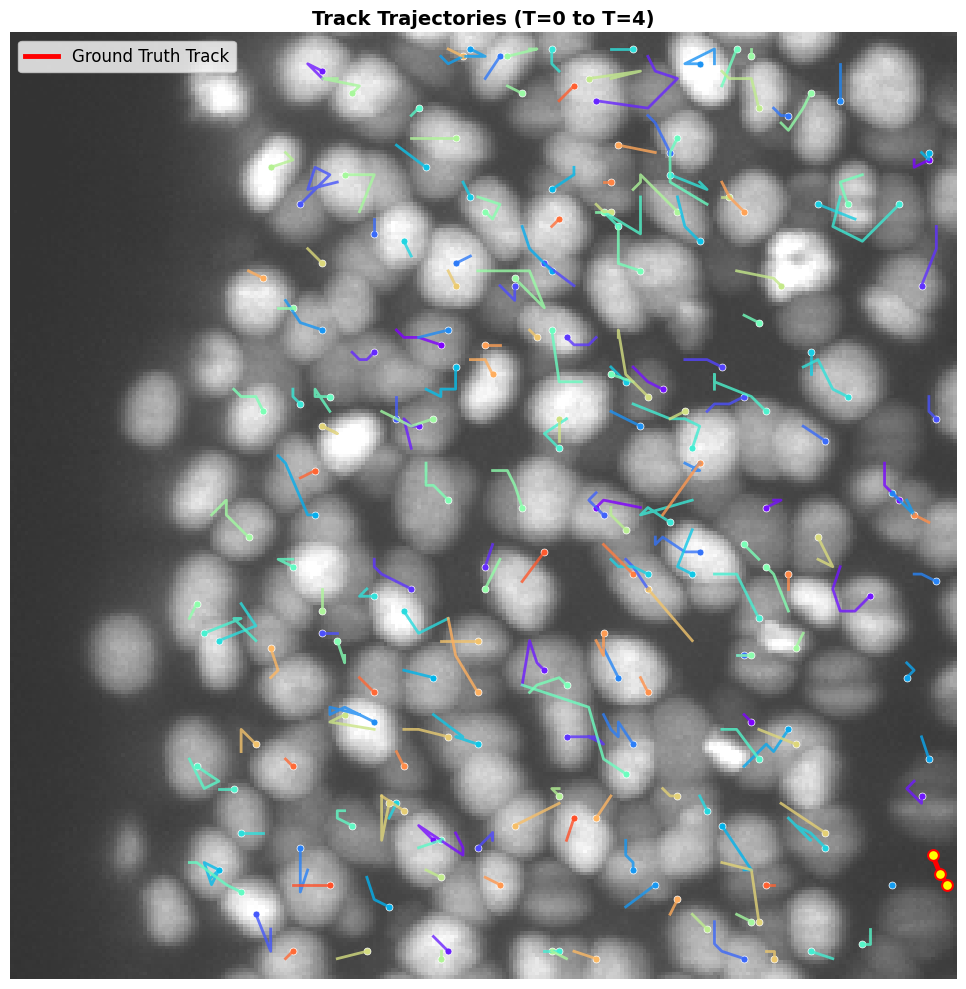

Successfully plotted trajectories for 211 tracked cells!


In [37]:
# Trajectories
import matplotlib.pyplot as plt
import numpy as np

# Create a figure showing the tracks moving across time
fig, ax = plt.subplots(figsize=(10, 10))

# 1. Background image: Frame 4 MIP
vol_last = np.asarray(arr[MAX_FRAMES - 1])
mip_last = vol_last.max(axis=0)
lo, hi = np.percentile(mip_last, [1, 99.5])
mip_norm = np.clip((mip_last - lo) / (hi - lo + 1e-8), 0, 1)

ax.imshow(mip_norm, cmap='gray', alpha=0.8)
ax.set_title(f"Track Trajectories (T=0 to T={MAX_FRAMES-1})", fontsize=14, fontweight='bold')

# 2. Draw tracks from tracker.tracks that lived for more than 1 frame
colors = plt.cm.rainbow(np.linspace(0, 1, len(tracker.tracks)))
tracked_count = 0

for i, track in enumerate(tracker.tracks):
    if len(track.history) > 1: # Only plot cells that were successfully tracked!
        tracked_count += 1
        history = np.array(track.history)
        # Note: history is [Z, Y, X], so X is history[:, 2], Y is history[:, 1]
        xs = history[:, 2]
        ys = history[:, 1]
        
        # Plot trajectory line and current position
        ax.plot(xs, ys, color=colors[i], linewidth=2.0, alpha=0.8)
        ax.scatter(xs[-1], ys[-1], color=colors[i], s=25, edgecolors='white', linewidth=0.5)

# 3. Overlay the Ground Truth trajectory (Red)
gt_coords_all = []
for t in range(MAX_FRAMES):
    if len(gt_by_t[t]) > 0:
        # Take the first GT cell
        gt_coords_all.append([gt_by_t[t][0][0], gt_by_t[t][0][1]])

if len(gt_coords_all) > 1:
    gt_coords_all = np.array(gt_coords_all)
    ax.plot(gt_coords_all[:, 0], gt_coords_all[:, 1], color='red', linewidth=3.5, label='Ground Truth Track')
    ax.scatter(gt_coords_all[:, 0], gt_coords_all[:, 1], color='yellow', s=60, edgecolors='red', linewidth=1.5, zorder=5)

ax.legend(loc='upper left', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig("/kaggle/working/cell_trajectories.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"Successfully plotted trajectories for {tracked_count} tracked cells!")